# Advanced Clustering Techniques

**Agenda**
1. Hierarchical Clustering
   - Agglomerative
   - Divisive methods
   - Linkage criteria
      - Single
      - Complete
      - Average Linkage

2. DBSCAN (Density-Based Spatial Clustering of Applications with Noise)
   - Concept and parameters (Epsilon, MinPts)
   - Process of DBSCAN
   - Advantages and Disadvantages

3. Mean-Shift Clustering
   - Key Concept
   - Mean-Shift Clustering Algorithm

4. Gaussian Mixture Models (GMM)
   - Key Concepts
   - GMM Formula
   - Parameter Estimation in GMM

## Hierarchical Clustering

- Hierarchical clustering is a type of unsupervised learning algorithm used to group similar data points into clusters based on their similarity.
- Unlike partitional clustering methods like K-means, which create a flat structure of clusters, hierarchical clustering builds a hierarchy of clusters, often represented as a tree-like diagram called a dendrogram.
- This approach can be categorized into two types: Agglomerative (bottom-up) and Divisive (top-down).

   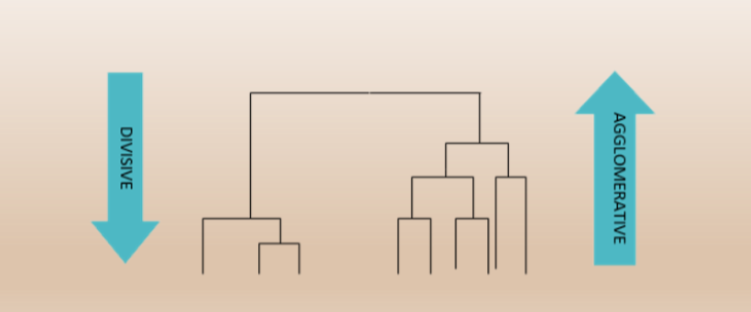

### Agglomerative Clustering (Bottom-Up Approach)

- This is the most commonly used type of hierarchical clustering.

- It starts with each data point as its own individual cluster and then iteratively merges the closest pairs of clusters until all the points are merged into a single cluster or until a stopping criterion is met (such as the desired number of clusters).

**Steps:**

   - Start with N clusters where each data point is its own cluster.
   - Find the pair of clusters that are the closest (according to some distance metric).
   - Merge these two clusters into a single cluster.
   - Repeat steps 2 and 3 until only one cluster remains or a predefined number of clusters is reached.

**Key Characteristics:**

   - It’s a bottom-up approach because it builds the tree from the leaves (individual points) upward.
   - Produces a nested hierarchy of clusters.
   - Distance metrics and linkage criteria play crucial roles in deciding which clusters to merge.

###  Divisive Clustering (Top-Down Approach)

- This is less commonly used but works in the opposite way of agglomerative clustering.

- It starts with all data points in a single cluster and iteratively splits them into smaller clusters until each data point is in its own cluster.

**Steps:**

   - Start with all data points in one cluster.
   - Split the cluster into two or more subclusters based on some criterion (e.g., distance, density).
   - Continue splitting the resulting clusters until each data point is its own cluster or a stopping condition is met.

**Key Characteristics:**

   - Top-down approach because it starts from the root (all data) and splits downward.
   - Less commonly used due to higher computational complexity.

#### Agglomerative vs Divisive Methods

**We'll implement Agglomerative Hierarchical Clustering since divisive is less commonly used.**

In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import AgglomerativeClustering, DBSCAN, MeanShift
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

**Generate Sample Data for Clustering**

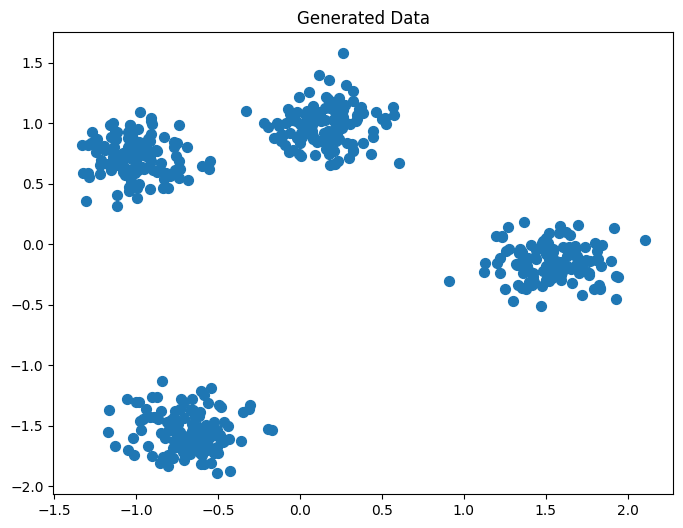

In [ ]:
# Generating synthetic data
X, _ = make_blobs(n_samples=500, centers=4, cluster_std=1.0, random_state=42)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Visualizing the synthetic data
plt.figure(figsize=(8, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], s=50)
plt.title("Generated Data")
plt.show()

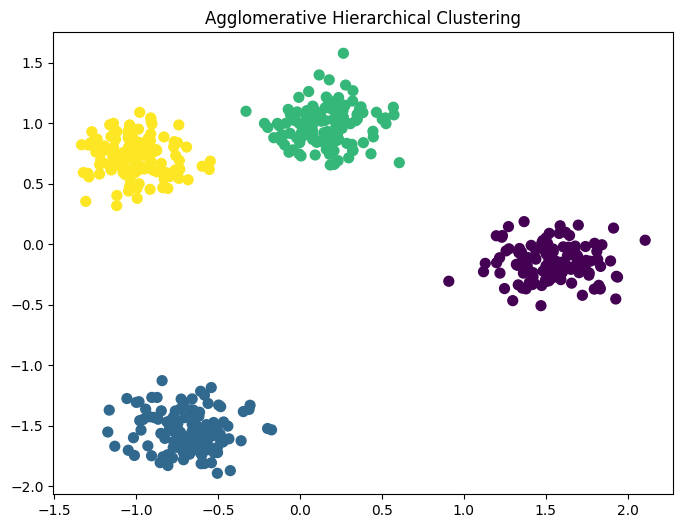

In [ ]:
# Performing agglomerative clustering
agg_cluster = AgglomerativeClustering(n_clusters=4, linkage='ward')
y_agg = agg_cluster.fit_predict(X_scaled)

# Visualizing the clusters
plt.figure(figsize=(8, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_agg, cmap='viridis', s=50)
plt.title("Agglomerative Hierarchical Clustering")
plt.show()

### Linkage Criteria in Hierarchical Clustering

Linkage criteria determine how the distance between clusters is calculated when merging or splitting clusters. Common linkage methods include:

#### Single Linkage (Minimum Linkage)

- The distance between two clusters is defined as the shortest distance between any two points in the two clusters.

- It tends to create long, "chain-like" clusters and is sensitive to outliers.

- Formula:

      d(A,B)=min{d(x,y)∣x∈A,y∈B}

#### Complete Linkage (Maximum Linkage)

- The distance between two clusters is the maximum distance between any two points in the two clusters.

- It generally results in compact, spherical clusters but can be influenced by outliers.

- Formula:

      d(A,B)=max{d(x,y)∣x∈A,y∈B}

#### Average Linkage

- The distance between two clusters is the average distance between all pairs of points from the two clusters.

- This method provides a balance between single and complete linkage.

- Formula:

   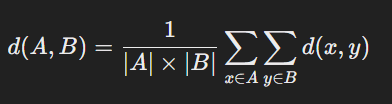

####  Dendrogram

- A dendrogram is a tree-like diagram that shows the arrangement of clusters formed at each step of hierarchical clustering. It is a visual representation of the hierarchy of clusters, where:

   - The height of each merger represents the distance (or dissimilarity) between the merged clusters.
   - Cutting the dendrogram at a certain height gives a desired number of clusters.
- The dendrogram helps in deciding the number of clusters by identifying a natural separation or distance threshold where clusters should be cut off.

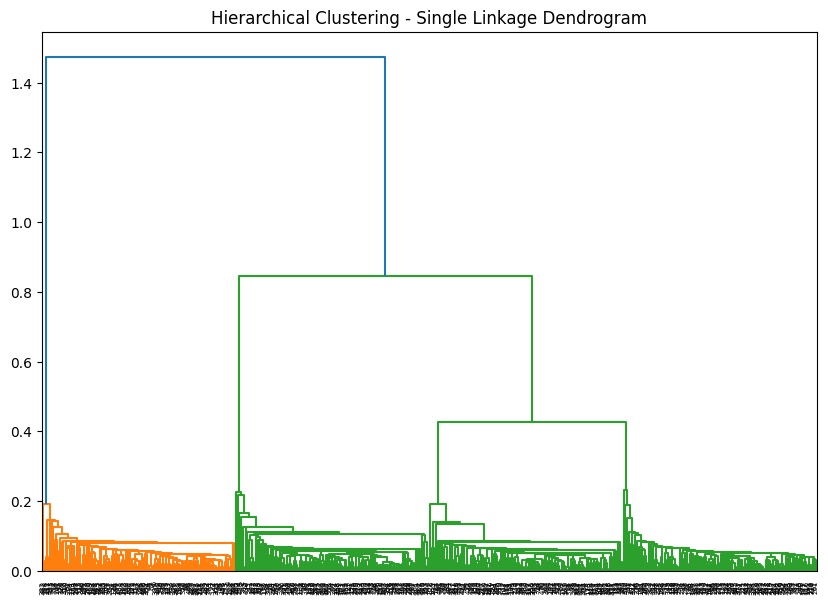

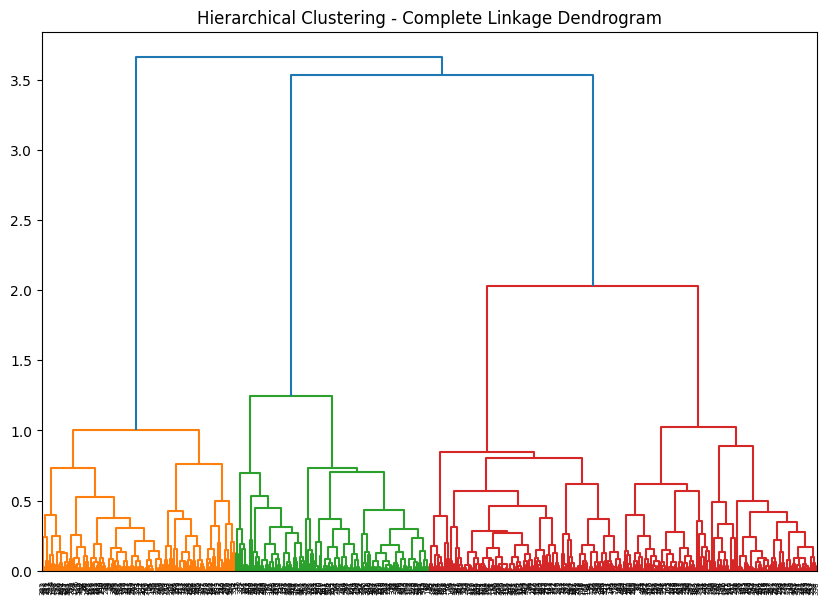

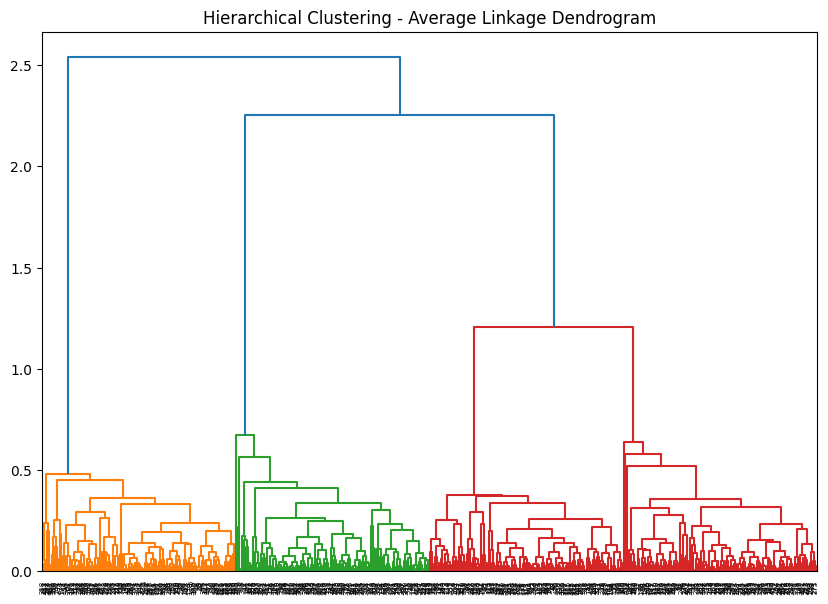

In [ ]:
# Performing hierarchical clustering with different linkage criteria
linked = linkage(X_scaled, 'single')  # Single linkage
plt.figure(figsize=(10, 7))
dendrogram(linked)
plt.title('Hierarchical Clustering - Single Linkage Dendrogram')
plt.show()

linked = linkage(X_scaled, 'complete')  # Complete linkage
plt.figure(figsize=(10, 7))
dendrogram(linked)
plt.title('Hierarchical Clustering - Complete Linkage Dendrogram')
plt.show()

linked = linkage(X_scaled, 'average')  # Average linkage
plt.figure(figsize=(10, 7))
dendrogram(linked)
plt.title('Hierarchical Clustering - Average Linkage Dendrogram')
plt.show()

## DBSCAN(Density-Based Spatial Clustering of Applications with Noise)

- DBSCAN (Density-Based Spatial Clustering of Applications with Noise) is a density-based clustering algorithm that identifies clusters in data by finding regions of high density separated by regions of low density.
- Unlike K-means or hierarchical clustering, DBSCAN does not require the number of clusters to be specified in advance and can detect clusters of arbitrary shape.
- It is especially effective for datasets with noise and outliers.

   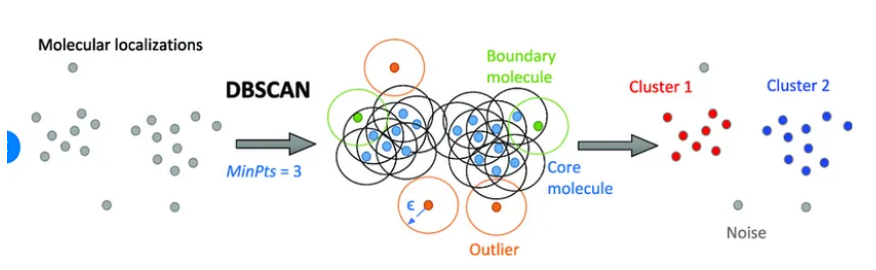

### Key Concepts of DBSCAN

- Core Points: A data point is considered a core point if it has at least a specified number of neighboring points (MinPts) within a certain distance (ε, epsilon).

- Border Points: A data point is a border point if it is not a core point but lies within the neighborhood of a core point.

- Noise Points (Outliers): A data point is classified as noise if it is neither a core point nor a border point, meaning it doesn't have enough neighbors to be part of any cluster.

### Parameters of DBSCAN

- Epsilon (ε): The value of ε is typically found using a k-distance plot, where for each point, the distance to its k-th nearest neighbor is calculated (with k = MinPts). The “elbow” of the plot suggests a suitable ε value.

- MinPts: The minimum number of points should typically be at least D+1, where D is the dimensionality of the data. However, a common rule of thumb is MinPts = 4 or higher, depending on the dataset.

### DBSCAN Algorithm

- Identify Core Points: For each point in the dataset, count how many other points fall within its ε-neighborhood (a circle of radius ε around the point). If the count is greater than or equal to MinPts, mark the point as a core point.

- Cluster Formation: For each core point, form a cluster by including all points that are directly density-reachable. This includes the core point and all points within its ε-neighborhood, which either directly or indirectly belong to the cluster (i.e., can be reached by following chains of core points).

- Handling Border and Noise Points:

   - Border Points: These are points within the neighborhood of a core point but with fewer than MinPts neighbors. They are assigned to the cluster of the core point.
   - Noise Points: Points that cannot be reached by any core point and do not have enough neighbors to be classified as a core or border point are marked as noise.

### Step-by-Step Process of DBSCAN

- Randomly select a point in the dataset.
- Check if it’s a core point:
   - If it has at least MinPts within its ε-neighborhood, it becomes a core point and a new cluster starts.
   - If it does not, mark it as noise temporarily (this may change later if it’s found to be in the neighborhood of a core point).
- Expand the cluster:
   - Add all points that are directly density-reachable from the core point.
   - For each point in the ε-neighborhood, check if it’s a core point, and if so, repeat the process.
   - Move to the next unvisited point and repeat until all points are processed.

### Advantages of DBSCAN

- No need to specify the number of clusters: Unlike K-means, DBSCAN does not require a pre-defined number of clusters.
- Can find clusters of arbitrary shape: DBSCAN can detect clusters of various shapes (e.g., non-spherical clusters), which makes it more versatile than algorithms like K-means.
- Handles outliers well: DBSCAN marks outliers as noise points, effectively separating them from the clusters.
- Works well with large datasets: Its complexity is generally lower compared to other clustering algorithms like hierarchical clustering.

### Disadvantages of DBSCAN

- Sensitive to the selection of ε and MinPts: The performance of DBSCAN is highly dependent on the correct selection of these parameters. A poorly chosen ε value may result in too many small clusters (underfitting) or a single large cluster (overfitting).
- Difficulty with varying density clusters: DBSCAN struggles with datasets where clusters have varying density, as a single value of ε may not work for all clusters.
- High-dimensional data: DBSCAN may struggle with high-dimensional data because it becomes difficult to define a meaningful neighborhood in high-dimensional space (due to the curse of dimensionality).

**Example of DBSCAN**

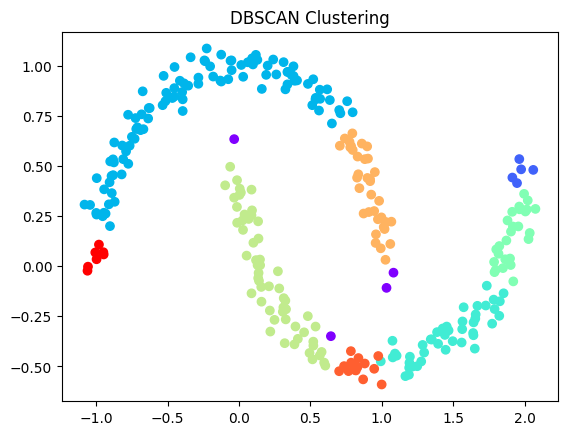

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt

# Generate sample data
X, _ = make_moons(n_samples=300, noise=0.05)

# Fit DBSCAN model
dbscan = DBSCAN(eps=0.1, min_samples=5)
y_db = dbscan.fit_predict(X)

# Plot the results
plt.scatter(X[:, 0], X[:, 1], c=y_db, cmap='rainbow')
plt.title("DBSCAN Clustering")
plt.show()

## Mean-Shift Clustering

- Mean-Shift Clustering is a non-parametric, iterative algorithm that clusters data by shifting data points towards areas of higher density.
- Unlike K-means or DBSCAN, Mean-Shift does not require the number of clusters to be specified beforehand and can automatically determine the number of clusters.
- It is particularly useful for discovering clusters in data without assumptions about their shapes or sizes.

   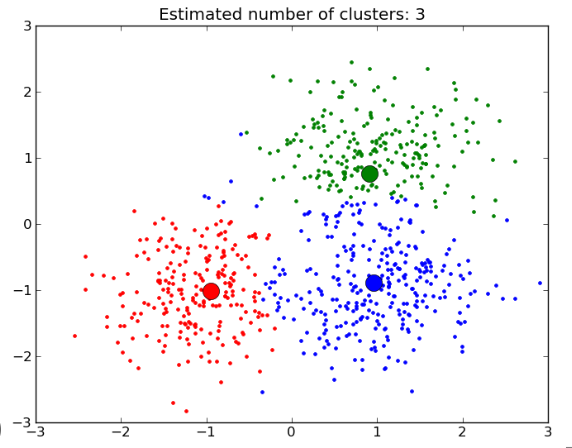

### Key Concepts in Mean-Shift Clustering

- Centroids: These are the points around which the clusters are formed. The algorithm updates centroids iteratively by shifting them towards regions of higher density in the data.

- Kernel Density Estimation (KDE): This is used to estimate the density of points in the data space. A kernel function, typically a Gaussian kernel, is used to compute the weighted average of points in the neighborhood of a centroid. The area of high density is where the centroids converge.

- Bandwidth: This is a crucial hyperparameter in Mean-Shift. It defines the radius or window size of the kernel function and determines how large the neighborhood is around each data point. A smaller bandwidth results in more clusters, while a larger bandwidth results in fewer clusters.

### Mean-Shift Clustering Algorithm

- The Mean-Shift algorithm works by iteratively moving data points (or centroids) towards areas of higher density. The algorithm starts by placing a kernel (usually a Gaussian) at each data point and then shifts the centroids towards the weighted mean of the points within a specified radius (bandwidth). This process repeats until convergence, i.e., until the centroids stop moving.

**Step-by-Step Process:**
- Initialize centroids: Start by treating each data point as a potential centroid.

- For each centroid:

   - Place a kernel (e.g., Gaussian) at the centroid.
   - Compute the mean of all points within the kernel window.
   - Shift the centroid towards this new mean (this is the "mean shift" step).
- Convergence:

   - Repeat the process of shifting the centroids until they converge, i.e., the shift becomes smaller than a predefined threshold, or the centroids no longer change significantly.
- Cluster Formation:

   - Once the centroids have converged, nearby centroids are merged, and clusters are formed based on the final positions of the centroids.
- Assign Points to Clusters:

   - Each data point is assigned to the nearest centroid, forming the final clusters.

**Example of Mean-Shift Clustering**

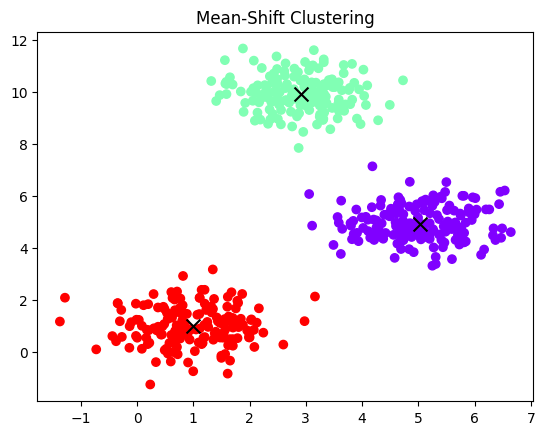

In [ ]:
from sklearn.cluster import MeanShift
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

# Generate sample data
centers = [[1, 1], [5, 5], [3, 10]]
X, _ = make_blobs(n_samples=500, centers=centers, cluster_std=0.7)

# Fit MeanShift model
ms = MeanShift(bandwidth=2)
ms.fit(X)
labels = ms.labels_
cluster_centers = ms.cluster_centers_

# Plot the results
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='rainbow')
plt.scatter(cluster_centers[:, 0], cluster_centers[:, 1], marker='x', color='black', s=100)
plt.title("Mean-Shift Clustering")
plt.show()

## Gaussian Mixture Models (GMM)

- Gaussian Mixture Models (GMM) are a probabilistic model used to represent a collection of normally distributed subpopulations within an overall population.
- GMM is a generalization of K-means clustering, which incorporates information about the variance of each cluster and allows for elliptical-shaped clusters, as opposed to spherical clusters in K-means.
- It models the data as a mixture of several Gaussian distributions, each representing a cluster.

   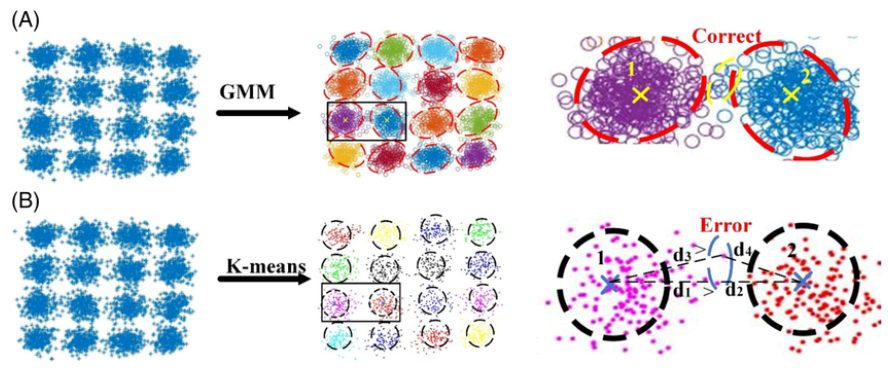

### Key Concepts in Gaussian Mixture Models

- Gaussian Distribution: A Gaussian (or normal) distribution is described by two parameters:

   - Mean (μ): It defines the center of the distribution.
   - Covariance (Σ): It defines the spread or the shape of the distribution. For multivariate data, covariance matrices are used to model the relationships between the variables.

**A Gaussian distribution in one dimension is represented by:**

   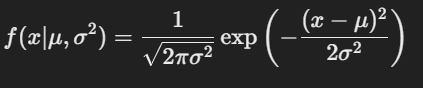

**For multivariate data, it becomes:**

   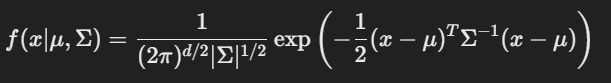

- Mixture of Gaussians: GMM assumes that the data is generated from a mixture of several Gaussian distributions. Each Gaussian distribution is defined by its mean vector (center of the cluster), covariance matrix (shape of the cluster), and a mixing coefficient (the proportion of the population belonging to that Gaussian).

- Latent Variables: GMM uses latent variables (hidden variables) to represent which Gaussian distribution a particular data point is drawn from. These latent variables are unknown and are estimated as part of the model.

- Mixing Coefficients: The mixing coefficient π<sub>k</sub> represents the weight of the k-th Gaussian in the overall model. These coefficients must satisfy:

   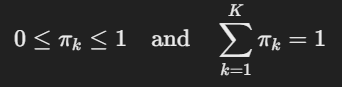


### Gaussian Mixture Model Formula

- The probability density function (PDF) for a GMM is the weighted sum of the PDFs of individual Gaussian distributions. If the model has
K components (Gaussian distributions), the PDF for a point
x is given by:

   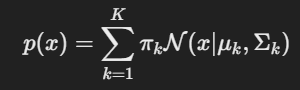

- Where:
   - π<sub>k</sub> is the mixing coefficient for the k-th Gaussian.

   - N(x∣μ<sub>k</sub>,Σ<sub>k</sub>) is the multivariate Gaussian distribution with mean μ<sub>k</sub> and covariance Σ<sub>k</sub> for component k.

### Parameter Estimation in GMM

- The parameters of the GMM (i.e., the means μ<sub>k</sub>, covariances Σ<sub>k</sub>, and mixing coefficients π<sub>k</sub>) are estimated using the Expectation-Maximization (EM) algorithm.
- EM is an iterative algorithm that alternates between assigning data points to clusters (E-step) and updating the model parameters (M-step) until convergence.

#### The Expectation-Maximization (EM) Algorithm

1. Initialization:

   - Initialize the parameters
μ<sub>k</sub>,
Σ<sub>k</sub>, and
π<sub>k</sub> randomly or using K-means clustering to get initial cluster centroids.

2. Expectation Step (E-step):
   - In this step, we calculate the probability (responsibility) that each data point belongs to each Gaussian component. This is done using Bayes' theorem:

   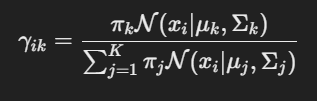

   Where γ<sub>ik</sub> is the probability that the i-th data point belongs to the k-th Gaussian (also known as the responsibility of component k for data point i).

3. Maximization Step (M-step):

   - Based on the responsibilities calculated in the E-step, we update the parameters μ<sub>k</sub>, Σ<sub>k</sub>, and π<sub>k</sub>:

   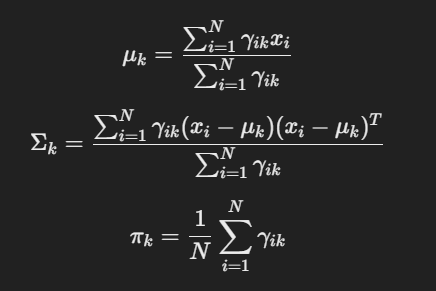

   These updates move the parameters towards maximizing the likelihood of the data given the current responsibilities.

4. Convergence:
  
   - Repeat the E-step and M-step until the model converges (i.e., the changes in the log-likelihood of the data become smaller than a predefined threshold or the number of iterations reaches a maximum limit).


**Here is a Python implementation of GMM using the sklearn.mixture.GaussianMixture class:**

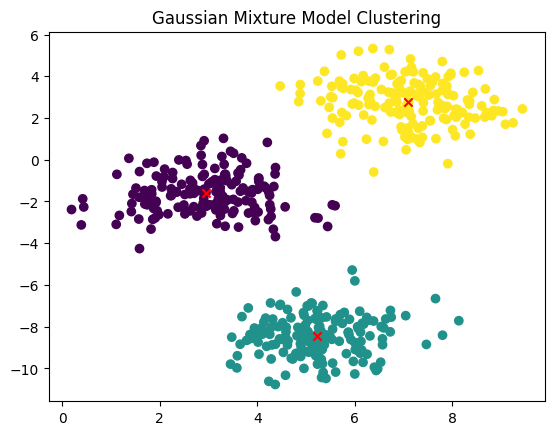

In [ ]:
from sklearn.mixture import GaussianMixture
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# Generate synthetic data
X, _ = make_blobs(n_samples=500, centers=3, cluster_std=1.0)

# Fit GMM model
gmm = GaussianMixture(n_components=3, covariance_type='full')
gmm.fit(X)

# Predict cluster labels
labels = gmm.predict(X)

# Plot the results
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', marker='o')
plt.scatter(gmm.means_[:, 0], gmm.means_[:, 1], c='red', marker='x')  # Plot cluster centers
plt.title('Gaussian Mixture Model Clustering')
plt.show()